In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("spam.csv", encoding='latin1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df[["Unnamed: 2", "Unnamed: 3",	"Unnamed: 4"]].isnull().sum()

,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [6]:
df = df.drop(columns = ["Unnamed: 2", "Unnamed: 3",	"Unnamed: 4"])

In [7]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.rename(columns = {"v1": "target", "v2": "message"}, inplace = True)

In [9]:
df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Checking for missing values

In [10]:
df.isna().sum()

,0
target,0
message,0


# checking for duplicate values and droping them if exists

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(5169, 2)

In [13]:
df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Applying Label encoding on target feature

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df["target"] = le.fit_transform(df["target"])

In [15]:
df.head()

,target,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
target_dist = df["target"].value_counts()

<Axes: xlabel='target'>

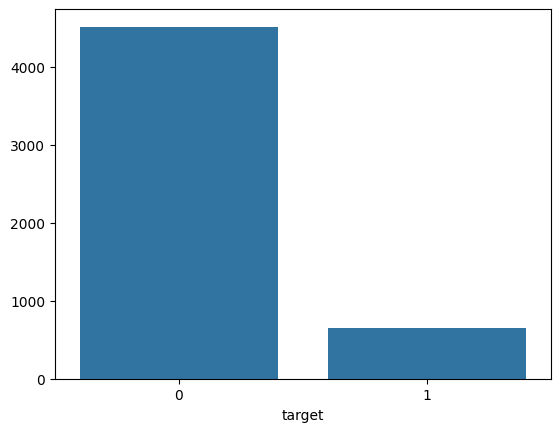

In [ ]:
sns.barplot(x=target_dist.index, y=target_dist.values)

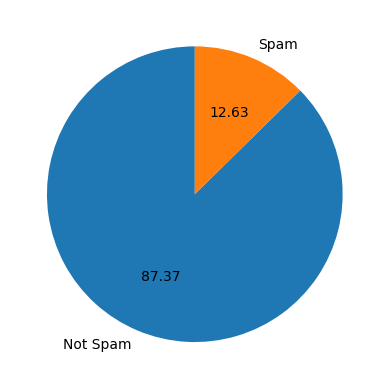

In [ ]:
plt.pie(df["target"].value_counts(), labels=["Not Spam", "Spam"], autopct="%0.2f", startangle=90)
plt.show()

Feature engineering

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df["no_of_chars"] = df["message"].apply(len)

In [ ]:
df.head()

,target,message,no_of_chars
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
df["no_of_words"] = df["message"].apply(lambda x: len(nltk.word_tokenize(x)))

In [ ]:
df.head()

,target,message,no_of_chars,no_of_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [ ]:
df["no_of_sentences"] = df["message"].apply(lambda x: len(nltk.sent_tokenize(x)))

In [ ]:
df.head()

,target,message,no_of_chars,no_of_words,no_of_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
target,5169.0,0.126330,0.332253,0.0,0.0,0.0,0.0,1.0
no_of_chars,5169.0,78.977945,58.236293,2.0,36.0,60.0,117.0,910.0
no_of_words,5169.0,18.455794,13.324758,1.0,9.0,15.0,26.0,220.0
no_of_sentences,5169.0,1.965564,1.448541,1.0,1.0,1.0,2.0,38.0


In [ ]:
df[df["no_of_chars"] == 2]

,target,message,no_of_chars,no_of_words,no_of_sentences
1924,0,Ok,2,1,1


In [ ]:
df[df["no_of_chars"] == 910]

,target,message,no_of_chars,no_of_words,no_of_sentences
1084,0,For me the love should start with attraction.i...,910,175,1


# Checking for Ham & spam

In [ ]:
df[df["target"] == 1][["no_of_chars", "no_of_words",	"no_of_sentences"]].describe()

,no_of_chars,no_of_words,no_of_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [ ]:
df[(df["target"] == 1) & (df["no_of_chars"] == 224)]

,target,message,no_of_chars,no_of_words,no_of_sentences
1733,1,"Hi, this is Mandy Sullivan calling from HOTMIX...",224,40,1


In [ ]:
df[df["target"] == 0][["no_of_chars", "no_of_words",	"no_of_sentences"]].describe()

,no_of_chars,no_of_words,no_of_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
df[(df["target"] == 0) & (df["no_of_chars"] == 910)]

,target,message,no_of_chars,no_of_words,no_of_sentences
1084,0,For me the love should start with attraction.i...,910,175,1


# Visualizing ham & spam msg's based on No of chars, words and sentences

In [ ]:
ham_dist_onChars = df[df["target"] == 0]["no_of_chars"]
spam_dist_onChars = df[df["target"] == 1]["no_of_chars"]

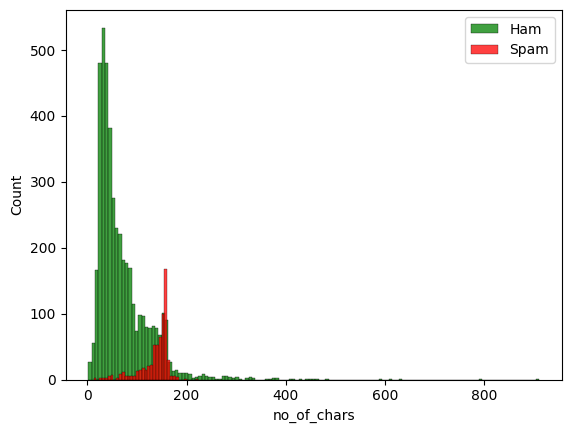

In [ ]:
sns.histplot(ham_dist_onChars, label="Ham", color="green")
sns.histplot(spam_dist_onChars, label="Spam", color="red")
plt.legend(["Ham", "Spam"])
plt.show()

In [ ]:
ham_dist_onWords = df[df["target"] == 0]["no_of_words"]
spam_dist_onWords = df[df["target"] == 1]["no_of_words"]

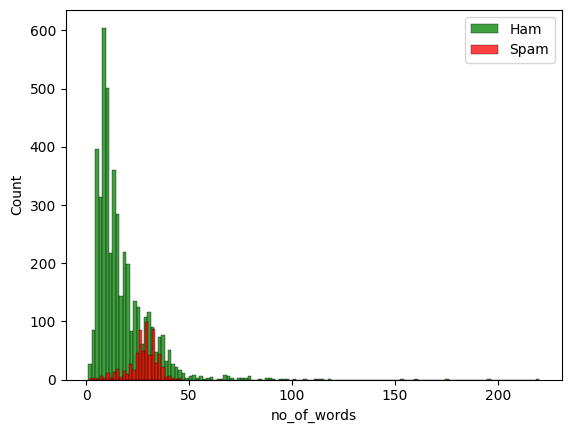

In [ ]:
sns.histplot(ham_dist_onWords, label="Ham", color="green")
sns.histplot(spam_dist_onWords, label="Spam", color="red")
plt.legend(["Ham", "Spam"])
plt.show()

<Axes: >

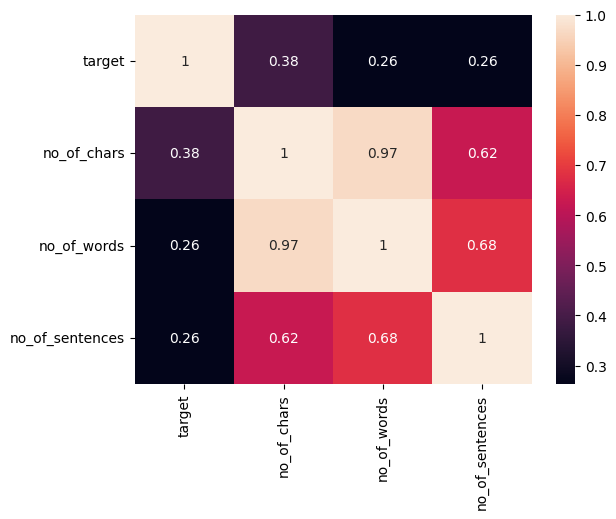

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# ML part

In [ ]:
df["message"][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [ ]:
import string
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [ ]:
def filtered_text(message):
  message = message.lower()
  message = nltk.word_tokenize(message)

  y = []
  for char in message:
    if char.isalnum():
      y.append(char)

  message = y[:]
  y.clear()

  for word in message:
    if word not in stopwords.words("english") and word not in string.punctuation:
      y.append(word)

  message = y[:]
  y.clear()

  for word in message:
    y.append(ps.stem(word))

  return " ".join(y)



In [ ]:
filtered_text(df["message"][0])
filtered_text("how are You~!@-=+}{} is and no to has shysg")

'shysg'

In [ ]:
df["filtered_text"] = df["message"].apply(filtered_text)

In [ ]:
df.head()

,target,message,no_of_chars,no_of_words,no_of_sentences,filtered_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


# Model selection and building

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=3000)


In [ ]:
df.columns

Index(['target', 'message', 'no_of_chars', 'no_of_words', 'no_of_sentences',
       'filtered_text'],
      dtype='object')

In [ ]:
X = tfidf.fit_transform(df["filtered_text"]).toarray()

In [ ]:
y = df["target"].values

Splitting data

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=9)

In [ ]:
X_train, X_test, y_train, y_test

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([0, 0, 0, ..., 0, 0, 0]),
 array([0, 1, 0, ..., 0, 0, 0]))

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [ ]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

# GNB model

In [ ]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)

In [ ]:
print(f"accuracy score: {accuracy_score(y_test, y_pred1)}")
print(f"confusion matrix: {confusion_matrix(y_test, y_pred1)}")
print(f"precision score: {precision_score(y_test, y_pred1)}")

accuracy score: 0.8562217923920051
confusion matrix: [[1174  181]
 [  42  154]]
precision score: 0.4597014925373134


# MNB

In [ ]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)

In [ ]:
print(f"accuracy score: {accuracy_score(y_test, y_pred2)}")
print(f"confusion matrix: {confusion_matrix(y_test, y_pred2)}")
print(f"precision score: {precision_score(y_test, y_pred2)}")

accuracy score: 0.968407479045777
confusion matrix: [[1355    0]
 [  49  147]]
precision score: 1.0


In [ ]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)

In [ ]:
print(f"accuracy score: {accuracy_score(y_test, y_pred3)}")
print(f"confusion matrix: {confusion_matrix(y_test, y_pred3)}")
print(f"precision score: {precision_score(y_test, y_pred3)}")

accuracy score: 0.97678916827853
confusion matrix: [[1352    3]
 [  33  163]]
precision score: 0.9819277108433735


# checking with other models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
lr = LogisticRegression()
dtc = DecisionTreeClassifier()
mnb = MultinomialNB()
knn = KNeighborsClassifier()

In [ ]:
ml_models = {
    "LR" : lr,
    "DTC" : dtc,
    "MNB" : mnb,
    "KNN" : knn
}

In [ ]:
def train_models(ml_models, X_train, y_train, X_test, y_test):
  ml_models.fit(X_train, y_train)
  y_pred = ml_models.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  precision = precision_score(y_test,y_pred)

  return accuracy, precision

In [ ]:
train_models(lr, X_train, y_train, X_test, y_test)

(0.9490651192778853, 0.9465648854961832)

In [ ]:
train_models(knn, X_train, y_train, X_test, y_test)

(0.9052224371373307, 0.9803921568627451)

In [ ]:
precision_scores = []
accuracy_scores = []

for model_name,model in ml_models.items():
  model_accuracy, model_precision = train_models(model, X_train, y_train, X_test, y_test)

  print(f"Model name: {model_name}")
  print(f"Precision score: {model_precision}")
  print(f"Accuracy score: {model_accuracy}")
  print()

  precision_scores.append(model_precision)
  accuracy_scores.append(model_accuracy)


Model name: LR
Precision score: 0.9465648854961832
Accuracy score: 0.9490651192778853

Model name: DTC
Precision score: 0.8167539267015707
Accuracy score: 0.9516441005802708

Model name: MNB
Precision score: 1.0
Accuracy score: 0.968407479045777

Model name: KNN
Precision score: 0.9803921568627451
Accuracy score: 0.9052224371373307



In [ ]:
model_performance = pd.DataFrame({"algorithm": ml_models.keys(), "precision_score": precision_scores, "accuracy_score": accuracy_scores})

In [ ]:
model_performance.sort_values('precision_score', ascending=False)

,algorithm,precision_score,accuracy_score
2,MNB,1.000000,0.968407
3,KNN,0.980392,0.905222
0,LR,0.946565,0.949065
1,DTC,0.816754,0.951644


In [ ]:
import pickle

In [ ]:
pickle.dump(tfidf, open("vectorized.pkl", "wb"))
pickle.dump(mnb, open("model.pkl", "wb"))